# 🚕 RL — Autonomous Decision Making (Taxi-v3)

> **Environment:** `Taxi-v3` (Gymnasium) — a 5×5 grid world  
> **Agent:** Robot taxi that must pick up a passenger and drop them at the correct location  
> **State space:** 500 discrete states · **Action space:** 6 (South, North, East, West, Pick-up, Drop-off)

| Approach | Type | Notes |
|---|---|---|
| **Random Policy** | Baseline | No learning |
| **Q-Learning** | Off-policy TD | Max Q next state |
| **SARSA** | On-policy TD | Actual next action |
| **DQN** | Deep RL (PyTorch) | MLP + replay buffer + target net |

In [15]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym

sns.set_theme(style='darkgrid', font_scale=1.05)
PALETTE = {'Random':'#95a5a6','Q-Learning':'#4C72B0','SARSA':'#55A868','DQN':'#C44E52'}

SEED = 42
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

# ── Hyper-parameters ────────────────────────────────────────────────────────
N_EPS      = 1500   # tabular agents
DQN_EPS    = 500    # DQN (faster: fewer but efficient)
MAX_STEPS  = 200
GAMMA      = 0.99
ALPHA      = 0.1    # tabular LR
EPS_START  = 1.0
EPS_END    = 0.05
EPS_DECAY  = 0.995

ENV_ID = 'Taxi-v3'
_e = gym.make(ENV_ID)
N_STATES, N_ACTIONS = _e.observation_space.n, _e.action_space.n
_e.close()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Env: {ENV_ID}  |  States: {N_STATES}  |  Actions: {N_ACTIONS}')
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')
print(f'Tabular: {N_EPS} eps  |  DQN: {DQN_EPS} eps')

Env: Taxi-v3  |  States: 500  |  Actions: 6
PyTorch 2.11.0+cpu  |  Device: cpu
Tabular: 1500 eps  |  DQN: 500 eps


## 1 · Environment Overview

In [16]:
action_names = ['South ↓','North ↑','East →','West ←','Pick-up','Drop-off']
print('Actions:', {i: n for i, n in enumerate(action_names)})
print('Rewards: +20 correct drop-off | -10 illegal | -1 per step')
e = gym.make(ENV_ID); obs, _ = e.reset(seed=0)
print(f'Sample state (encoded): {obs}'); e.close()

Actions: {0: 'South ↓', 1: 'North ↑', 2: 'East →', 3: 'West ←', 4: 'Pick-up', 5: 'Drop-off'}
Rewards: +20 correct drop-off | -10 illegal | -1 per step
Sample state (encoded): 314


## 2 · Baseline — Random Policy

In [17]:
def run_random(n=N_EPS):
    env = gym.make(ENV_ID)
    rews, steps = [], []
    for ep in range(n):
        obs, _ = env.reset(seed=ep); tot, s = 0, 0
        for _ in range(MAX_STEPS):
            obs, r, d, t, _ = env.step(env.action_space.sample())
            tot += r; s += 1
            if d or t: break
        rews.append(tot); steps.append(s)
    env.close()
    return np.array(rews), np.array(steps)

rand_r, rand_s = run_random()
print(f'Random   Mean={rand_r.mean():.2f}  Success={( rand_r>0).mean()*100:.1f}%')

Random   Mean=-772.83  Success=0.0%


## 3 · Q-Learning (Off-policy TD)

In [18]:
def run_q_learning(n=N_EPS):
    env = gym.make(ENV_ID)
    Q = np.zeros((N_STATES, N_ACTIONS)); eps = EPS_START
    rews, steps = [], []
    for ep in range(n):
        obs, _ = env.reset(seed=ep); tot, s = 0, 0
        for _ in range(MAX_STEPS):
            a = env.action_space.sample() if np.random.random() < eps else np.argmax(Q[obs])
            nobs, r, d, t, _ = env.step(a)
            Q[obs, a] += ALPHA * (r + GAMMA * np.max(Q[nobs]) * (not d) - Q[obs, a])
            obs = nobs; tot += r; s += 1
            if d or t: break
        eps = max(EPS_END, eps * EPS_DECAY)
        rews.append(tot); steps.append(s)
    env.close()
    return Q, np.array(rews), np.array(steps)

q_table, q_r, q_s = run_q_learning()
print(f'Q-Learn  Mean={q_r.mean():.2f}  Last-200={q_r[-200:].mean():.2f}  Success={( q_r>0).mean()*100:.1f}%')

Q-Learn  Mean=-114.26  Last-200=3.13  Success=33.4%


## 4 · SARSA (On-policy TD)

In [19]:
def run_sarsa(n=N_EPS):
    env = gym.make(ENV_ID)
    Q = np.zeros((N_STATES, N_ACTIONS)); eps = EPS_START
    rews, steps = [], []
    eg = lambda s: env.action_space.sample() if np.random.random() < eps else int(np.argmax(Q[s]))
    for ep in range(n):
        obs, _ = env.reset(seed=ep); a = eg(obs); tot, s = 0, 0
        for _ in range(MAX_STEPS):
            nobs, r, d, t, _ = env.step(a); na = eg(nobs)
            Q[obs, a] += ALPHA * (r + GAMMA * Q[nobs, na] * (not d) - Q[obs, a])
            obs, a = nobs, na; tot += r; s += 1
            if d or t: break
        eps = max(EPS_END, eps * EPS_DECAY)
        rews.append(tot); steps.append(s)
    env.close()
    return Q, np.array(rews), np.array(steps)

sarsa_table, sarsa_r, sarsa_s = run_sarsa()
print(f'SARSA    Mean={sarsa_r.mean():.2f}  Last-200={sarsa_r[-200:].mean():.2f}  Success={( sarsa_r>0).mean()*100:.1f}%')

SARSA    Mean=-114.82  Last-200=1.04  Success=30.4%


## 5 · DQN — Deep Q-Network (PyTorch)

Standard DQN with **PyTorch MLP**, **experience replay**, and **target network**. Optimised for speed: 500 episodes, hidden=64, train every 4 steps.

In [20]:
class DQNNet(nn.Module):
    def __init__(self, n_s, n_a, h=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_s,h), nn.ReLU(), nn.Linear(h,h), nn.ReLU(), nn.Linear(h,n_a))
    def forward(self, x): return self.net(x)

class ReplayBuffer:
    def __init__(self, cap=3000): self.buf = deque(maxlen=cap)
    def push(self, *args): self.buf.append(args)
    def sample(self, n):
        b = random.sample(self.buf, n); s,a,r,ns,d = zip(*b)
        return (torch.tensor(np.array(s), dtype=torch.float32, device=DEVICE),
                torch.tensor(a, dtype=torch.long, device=DEVICE),
                torch.tensor(r, dtype=torch.float32, device=DEVICE),
                torch.tensor(np.array(ns), dtype=torch.float32, device=DEVICE),
                torch.tensor(d, dtype=torch.bool, device=DEVICE))
    def __len__(self): return len(self.buf)

def oh(s, n=N_STATES):
    v = np.zeros(n, dtype=np.float32); v[s] = 1.0; return v

def run_dqn(n=DQN_EPS, h=64, lr=5e-3, bs=32, sync=25, train_every=4):
    env = gym.make(ENV_ID)
    online = DQNNet(N_STATES, N_ACTIONS, h).to(DEVICE)
    target = DQNNet(N_STATES, N_ACTIONS, h).to(DEVICE)
    target.load_state_dict(online.state_dict()); target.eval()
    opt = optim.Adam(online.parameters(), lr=lr)
    buf = ReplayBuffer(); eps = EPS_START
    rews, steps, step_count = [], [], 0
    for ep in range(n):
        obs, _ = env.reset(seed=ep); obs_oh = oh(obs); tot, s = 0, 0
        for _ in range(MAX_STEPS):
            if random.random() < eps:
                act = env.action_space.sample()
            else:
                with torch.no_grad():
                    act = int(online(torch.tensor(obs_oh, device=DEVICE).unsqueeze(0)).argmax())
            nobs, r, d, t, _ = env.step(act)
            nobs_oh = oh(nobs)
            buf.push(obs_oh, act, r, nobs_oh, d or t)
            obs_oh = nobs_oh; tot += r; s += 1; step_count += 1
            # Train every 4 steps (big speed-up vs every step)
            if len(buf) >= bs and step_count % train_every == 0:
                sb, ab, rb, nsb, db = buf.sample(bs)
                with torch.no_grad():
                    tgt = rb + GAMMA * target(nsb).max(1).values * (~db)
                q = online(sb).gather(1, ab.unsqueeze(1)).squeeze(1)
                loss = F.mse_loss(q, tgt)
                opt.zero_grad(); loss.backward(); opt.step()
            if d or t: break
        if (ep+1) % sync == 0: target.load_state_dict(online.state_dict())
        eps = max(EPS_END, eps * EPS_DECAY)
        rews.append(tot); steps.append(s)
    env.close()
    return online, np.array(rews), np.array(steps)

print('Training DQN (PyTorch) — 500 eps, hidden=64, train every 4 steps...')
dqn_model, dqn_r, dqn_s = run_dqn()
print(f'DQN      Mean={dqn_r.mean():.2f}  Last-100={dqn_r[-100:].mean():.2f}  Success={( dqn_r>0).mean()*100:.1f}%')

Training DQN (PyTorch) — 500 eps, hidden=64, train every 4 steps...
DQN      Mean=-392.69  Last-100=-240.32  Success=0.6%


## 6 · Learning Curves

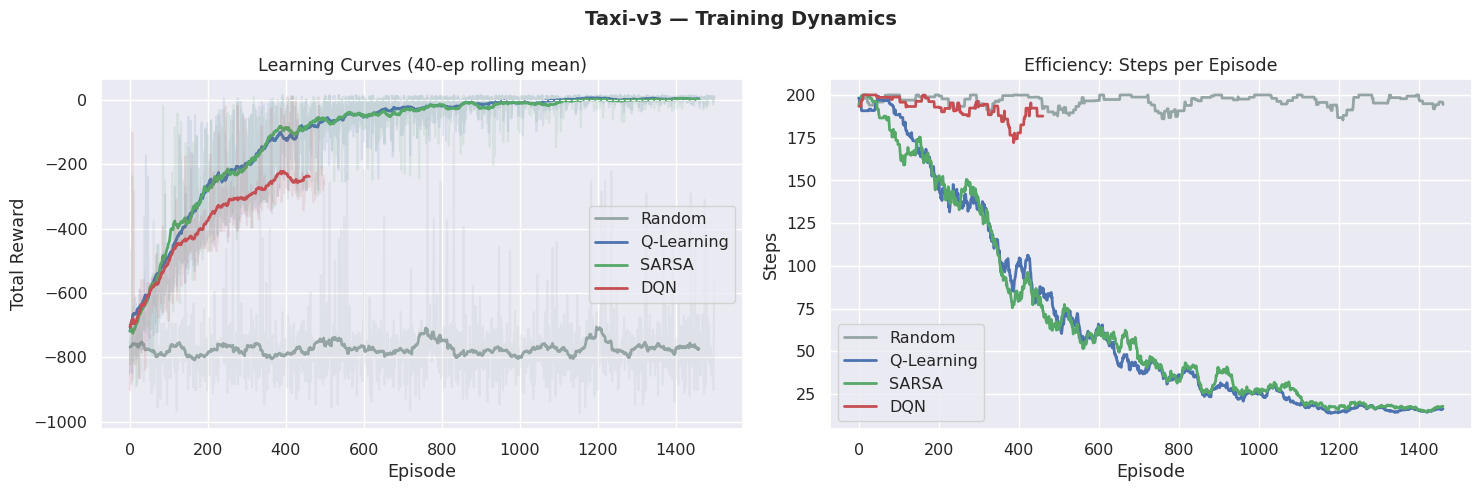

In [21]:
def smooth(x, w=40): return np.convolve(x, np.ones(w)/w, mode='valid')

all_r = {'Random': rand_r, 'Q-Learning': q_r, 'SARSA': sarsa_r, 'DQN': dqn_r}
all_s = {'Random': rand_s, 'Q-Learning': q_s, 'SARSA': sarsa_s, 'DQN': dqn_s}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, rews in all_r.items():
    axes[0].plot(rews, alpha=0.12, color=PALETTE[name])
    axes[0].plot(smooth(rews), color=PALETTE[name], lw=2, label=name)
axes[0].set(xlabel='Episode', ylabel='Total Reward', title='Learning Curves (40-ep rolling mean)')
axes[0].legend(); axes[0].axhline(0, color='white', lw=0.8, ls='--')

for name, st in all_s.items():
    axes[1].plot(smooth(st), color=PALETTE[name], lw=2, label=name)
axes[1].set(xlabel='Episode', ylabel='Steps', title='Efficiency: Steps per Episode')
axes[1].legend()
plt.suptitle('Taxi-v3 — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 7 · Compare Agents

In [22]:
def last_mean(arr, w): return arr[-w:].mean()

rows = []
for name, rews in all_r.items():
    w = 100 if name == 'DQN' else 200
    rows.append({'Agent':name, 'Mean Reward':rews.mean(),
                 'Last-N Mean':last_mean(rews,w), 'Success %':(rews>0).mean()*100,
                 'Avg Steps':all_s[name].mean()})

summary = pd.DataFrame(rows).sort_values('Last-N Mean', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False, float_format='{:.2f}'.format))
print(f"\n🏆  Best agent: {summary.iloc[0]['Agent']}")

     Agent  Mean Reward  Last-N Mean  Success %  Avg Steps
Q-Learning      -114.26         3.13      33.40      68.88
     SARSA      -114.82         1.04      30.40      69.07
       DQN      -392.69      -240.32       0.60     192.35
    Random      -772.83      -770.30       0.00     196.45

🏆  Best agent: Q-Learning


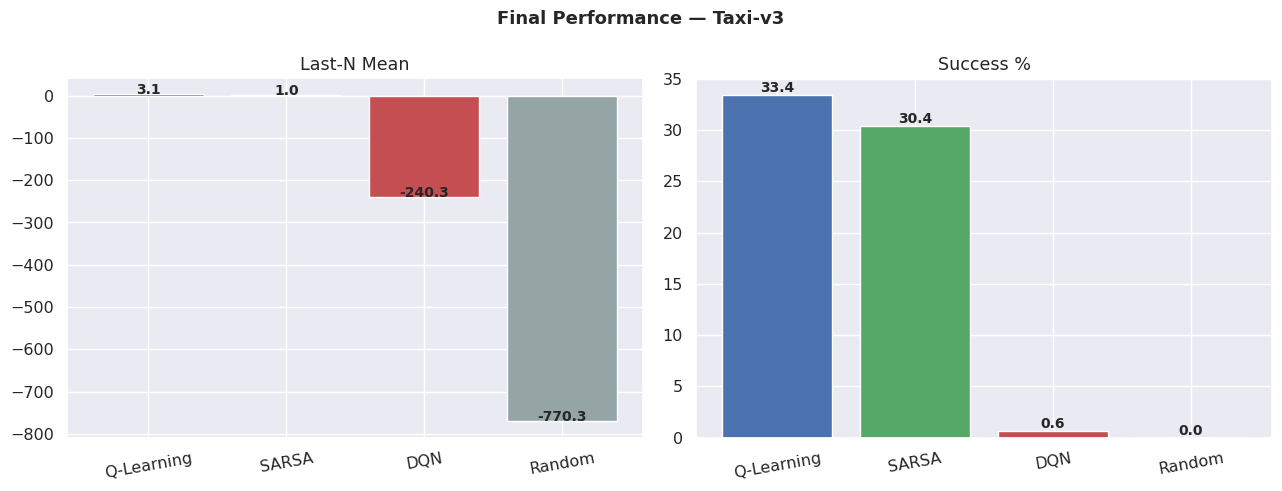

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['Last-N Mean', 'Success %']):
    colors = [PALETTE[a] for a in summary['Agent']]
    bars = ax.bar(summary['Agent'], summary[metric], color=colors, edgecolor='white')
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(metric); ax.tick_params(axis='x', rotation=10)
plt.suptitle('Final Performance — Taxi-v3', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 8 · Q-Table Heatmap

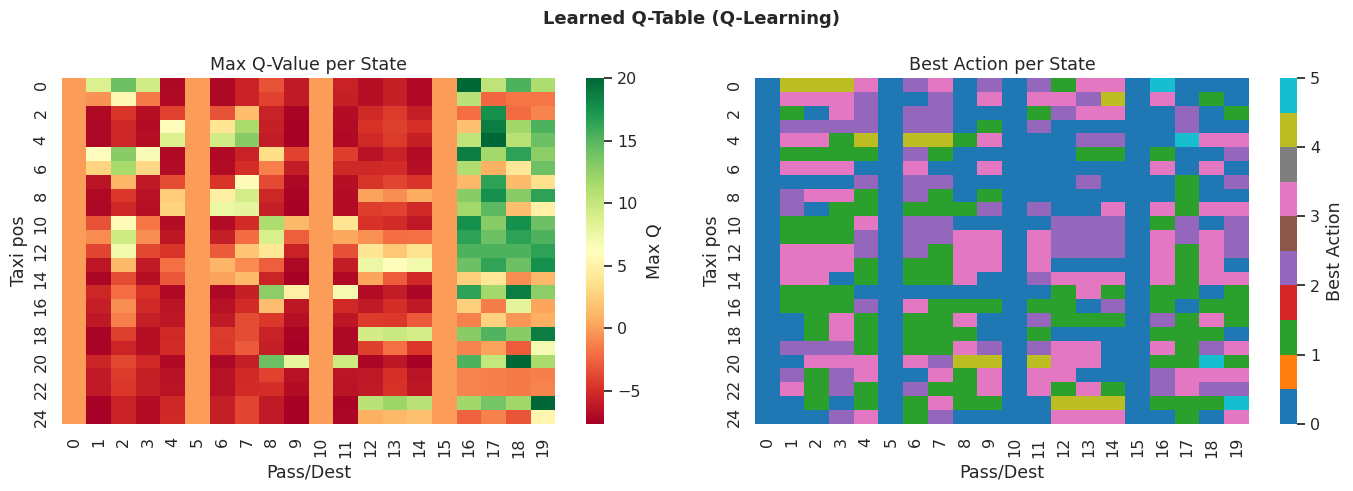

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(q_table.max(1).reshape(25,20), ax=axes[0], cmap='RdYlGn', cbar_kws={'label':'Max Q'})
axes[0].set(title='Max Q-Value per State', xlabel='Pass/Dest', ylabel='Taxi pos')
sns.heatmap(np.argmax(q_table,1).reshape(25,20), ax=axes[1], cmap='tab10', vmin=0, vmax=5, cbar_kws={'label':'Best Action'})
axes[1].set(title='Best Action per State', xlabel='Pass/Dest', ylabel='Taxi pos')
plt.suptitle('Learned Q-Table (Q-Learning)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 9 · Greedy Evaluation — 200 Unseen Episodes

In [25]:
def evaluate(fn, n=200):
    env = gym.make(ENV_ID); rews=[]; 
    for ep in range(n):
        obs,_=env.reset(seed=ep+50000); tot=0
        for _ in range(MAX_STEPS):
            obs,r,d,t,_=env.step(fn(obs)); tot+=r
            if d or t: break
        rews.append(tot)
    env.close(); rews=np.array(rews)
    return rews.mean(), (rews>0).mean()*100

def dqn_act(s):
    dqn_model.eval()
    with torch.no_grad():
        return int(dqn_model(torch.tensor(oh(s),device=DEVICE).unsqueeze(0)).argmax())

agents_eval = {'Random':lambda s: np.random.randint(N_ACTIONS),
               'Q-Learning':lambda s:int(np.argmax(q_table[s])),
               'SARSA':lambda s:int(np.argmax(sarsa_table[s])),
               'DQN':dqn_act}

print(f'{"Agent":15}  {"Eval Reward":>12}  {"Success %":>10}')
print('-'*42)
for name, fn in agents_eval.items():
    mr, sc = evaluate(fn)
    print(f'{name:15}  {mr:12.2f}  {sc:10.1f}%')

Agent             Eval Reward   Success %
------------------------------------------
Random                -768.54         0.0%
Q-Learning             -75.71        68.0%
SARSA                  -60.91        66.5%
DQN                   -200.00         0.0%
